STEP 1: LOADING HEART DISEASE DATASET
✅ Dataset loaded successfully!
📊 Dataset shape: (303, 14)

First 5 rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca thal  target  
0    3.0  0.0  6.0       0  
1    2.0  3.0  3.0       2  
2    2.0  2.0  7.0       1  
3    3.0  0.0  3.0       0  
4    1.0  0.0  3.0       0  

STEP 2: DATA CLEANING

Missing values before cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0


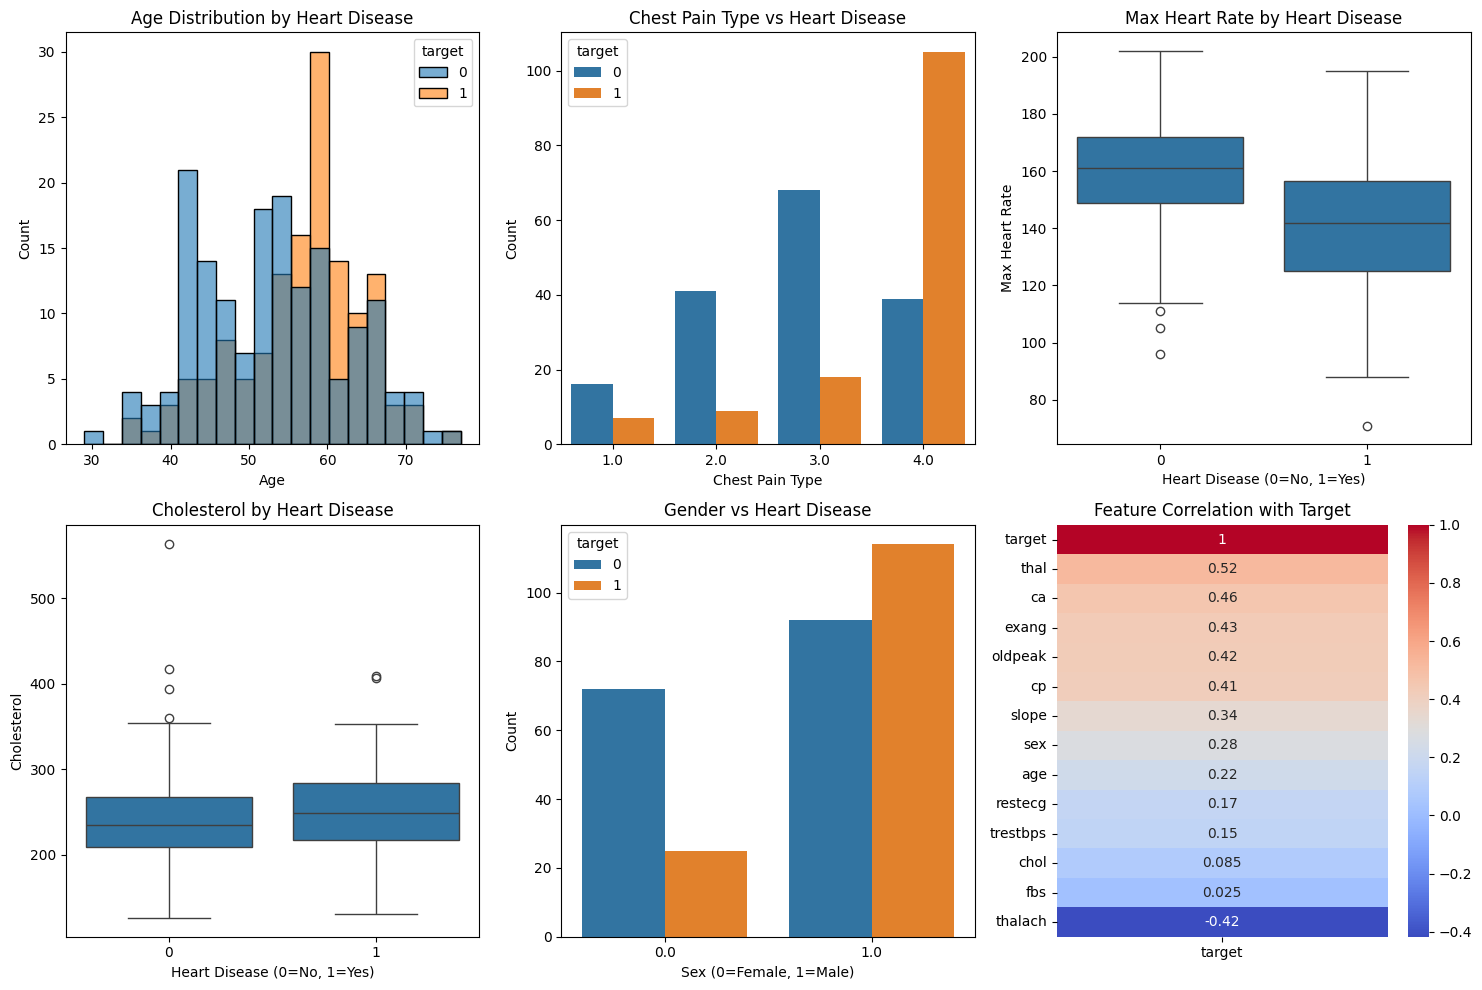


STEP 5: DATA PREPARATION
Features shape: (303, 13)
Target shape: (303,)

Features used: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Training set size: 242
Testing set size: 61

STEP 6: TRAINING MODELS
✅ Logistic Regression trained
✅ Decision Tree trained

STEP 7: MODEL EVALUATION

📊 Model Accuracy:
   Logistic Regression: 0.8689 (86.89%)
   Decision Tree: 0.7869 (78.69%)

📊 Confusion Matrices:

Logistic Regression:
            Predicted No  Predicted Yes
Actual No             27              6
Actual Yes             2             26

Decision Tree:
            Predicted No  Predicted Yes
Actual No             24              9
Actual Yes             4             24

📊 Classification Report - Logistic Regression:
              precision    recall  f1-score   support

  No Disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.8

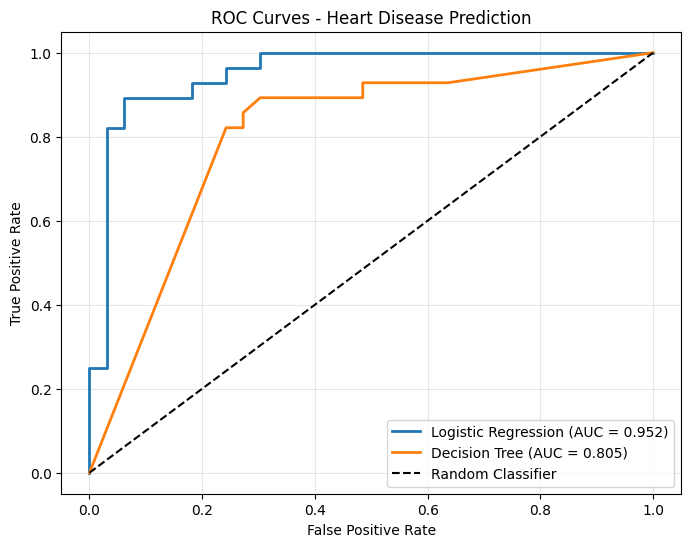


STEP 9: FEATURE IMPORTANCE ANALYSIS

📊 Top 10 Most Important Features:
Feature  Importance
   thal    0.378859
     cp    0.151595
     ca    0.116874
    age    0.092980
   chol    0.082157
oldpeak    0.065886
thalach    0.041809
  slope    0.031752
    sex    0.026142
    fbs    0.008802


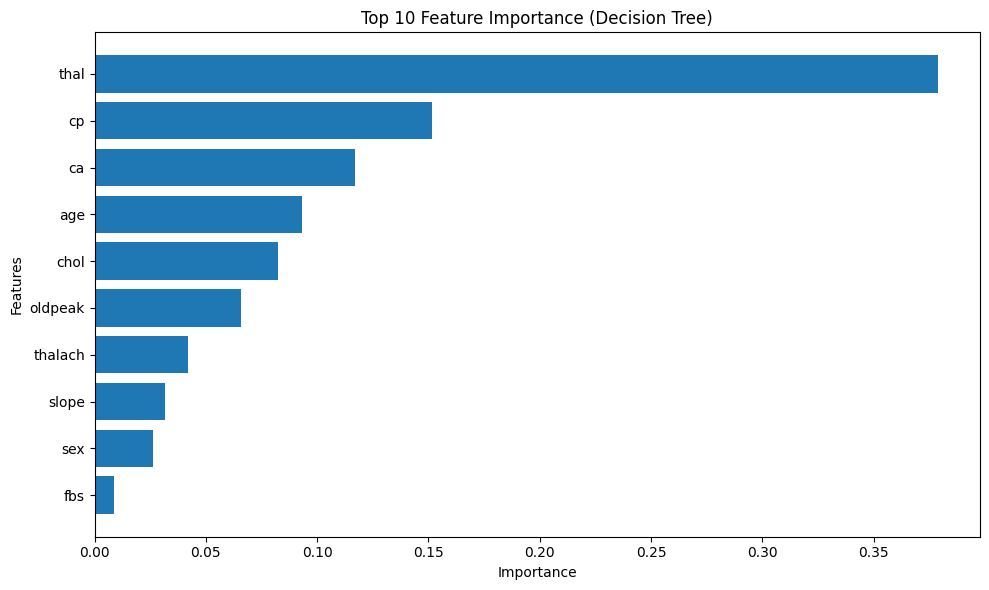


STEP 10: KEY INSIGHTS - IMPORTANT FEATURES

🔍 MOST IMPORTANT FEATURES FOR HEART DISEASE PREDICTION:

1. thal - (Importance: 0.3789)
   Description: thal

2. cp - (Importance: 0.1516)

3. ca - (Importance: 0.1169)

4. age - (Importance: 0.0930)

5. chol - (Importance: 0.0822)

💡 INSIGHT: These features are the strongest predictors of heart disease.
   - Higher importance means the feature strongly influences the prediction
   - Doctors should pay special attention to these factors during diagnosis



In [7]:
# Task 3: Heart Disease Prediction
# By : Saif Ullah
# AI/ML Engineering Internship - DevelopersHub Corporation

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report
import warnings
warnings.filterwarnings('ignore')

# ============================================
# STEP 1: LOAD THE DATASET
# ============================================
print("="*60)
print("STEP 1: LOADING HEART DISEASE DATASET")
print("="*60)

# Load dataset from URL (UCI Heart Disease Dataset)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
           'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv(url, names=columns)

print(f"✅ Dataset loaded successfully!")
print(f"📊 Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

# ============================================
# STEP 2: CLEAN THE DATASET (HANDLE MISSING VALUES)
# ============================================
print("\n" + "="*60)
print("STEP 2: DATA CLEANING")
print("="*60)

# Check for missing values
print("\nMissing values before cleaning:")
print(df.isnull().sum())

# Replace '?' with NaN and handle missing values
df = df.replace('?', np.nan)

# Convert columns to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col])

# Check missing values again
print("\nMissing values after conversion:")
print(df.isnull().sum())

# Fill missing values with median
df = df.fillna(df.median())

print("\n✅ Missing values handled successfully!")
print(f"Dataset shape after cleaning: {df.shape}")

# ============================================
# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================
print("\n" + "="*60)
print("STEP 3: EXPLORATORY DATA ANALYSIS")
print("="*60)

# Target variable distribution
print("\n🎯 Target Distribution:")
print(df['target'].value_counts())
print(f"\nPercentage:")
print(df['target'].value_counts(normalize=True) * 100)

# Convert target to binary (0 = no disease, 1 = disease)
df['target'] = (df['target'] > 0).astype(int)
print(f"\n✅ Converted to binary classification:")
print(f"   0 = No Heart Disease: {len(df[df['target']==0])} samples")
print(f"   1 = Heart Disease: {len(df[df['target']==1])} samples")

# Basic statistics by target
print("\n📊 Statistics by Heart Disease Status:")
print(df.groupby('target').mean())

# ============================================
# STEP 4: VISUALIZE DATA TRENDS
# ============================================
print("\n" + "="*60)
print("STEP 4: VISUALIZING DATA TRENDS")
print("="*60)

plt.figure(figsize=(15, 10))

# 4.1 Age distribution by heart disease status
plt.subplot(2, 3, 1)
sns.histplot(data=df, x='age', hue='target', bins=20, alpha=0.6)
plt.title('Age Distribution by Heart Disease')
plt.xlabel('Age')
plt.ylabel('Count')

# 4.2 Chest pain type distribution
plt.subplot(2, 3, 2)
sns.countplot(data=df, x='cp', hue='target')
plt.title('Chest Pain Type vs Heart Disease')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')

# 4.3 Heart rate distribution
plt.subplot(2, 3, 3)
sns.boxplot(data=df, x='target', y='thalach')
plt.title('Max Heart Rate by Heart Disease')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Max Heart Rate')

# 4.4 Cholesterol distribution
plt.subplot(2, 3, 4)
sns.boxplot(data=df, x='target', y='chol')
plt.title('Cholesterol by Heart Disease')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Cholesterol')

# 4.5 Gender distribution
plt.subplot(2, 3, 5)
sns.countplot(data=df, x='sex', hue='target')
plt.title('Gender vs Heart Disease')
plt.xlabel('Sex (0=Female, 1=Male)')
plt.ylabel('Count')

# 4.6 Correlation heatmap
plt.subplot(2, 3, 6)
corr_matrix = df.corr()
sns.heatmap(corr_matrix[['target']].sort_values(by='target', ascending=False),
            annot=True, cmap='coolwarm')
plt.title('Feature Correlation with Target')

plt.tight_layout()
plt.savefig('heart_disease_eda.png')
plt.show()

# ============================================
# STEP 5: PREPARE DATA FOR MODELING
# ============================================
print("\n" + "="*60)
print("STEP 5: DATA PREPARATION")
print("="*60)

# Define features and target
X = df.drop('target', axis=1)
y = df['target']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures used: {list(X.columns)}")

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

# ============================================
# STEP 6: TRAIN CLASSIFICATION MODELS
# ============================================
print("\n" + "="*60)
print("STEP 6: TRAINING MODELS")
print("="*60)

# 6.1 Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_pred_prob = lr_model.predict_proba(X_test)[:, 1]
print("✅ Logistic Regression trained")

# 6.2 Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_pred_prob = dt_model.predict_proba(X_test)[:, 1]
print("✅ Decision Tree trained")

# ============================================
# STEP 7: EVALUATE MODELS
# ============================================
print("\n" + "="*60)
print("STEP 7: MODEL EVALUATION")
print("="*60)

# 7.1 Accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)
dt_accuracy = accuracy_score(y_test, dt_pred)

print("\n📊 Model Accuracy:")
print(f"   Logistic Regression: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")
print(f"   Decision Tree: {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")

# 7.2 Confusion Matrices
print("\n📊 Confusion Matrices:")

print("\nLogistic Regression:")
lr_cm = confusion_matrix(y_test, lr_pred)
print(pd.DataFrame(lr_cm, columns=['Predicted No', 'Predicted Yes'],
                   index=['Actual No', 'Actual Yes']))

print("\nDecision Tree:")
dt_cm = confusion_matrix(y_test, dt_pred)
print(pd.DataFrame(dt_cm, columns=['Predicted No', 'Predicted Yes'],
                   index=['Actual No', 'Actual Yes']))

# 7.3 Classification Reports
print("\n📊 Classification Report - Logistic Regression:")
print(classification_report(y_test, lr_pred, target_names=['No Disease', 'Disease']))

print("\n📊 Classification Report - Decision Tree:")
print(classification_report(y_test, dt_pred, target_names=['No Disease', 'Disease']))

# ============================================
# STEP 8: ROC CURVE
# ============================================
print("\n" + "="*60)
print("STEP 8: ROC CURVE ANALYSIS")
print("="*60)

# Calculate ROC curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_pred_prob)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_pred_prob)

# Calculate AUC scores
lr_auc = auc(lr_fpr, lr_tpr)
dt_auc = auc(dt_fpr, dt_tpr)

print(f"\n📈 AUC Scores:")
print(f"   Logistic Regression AUC: {lr_auc:.4f}")
print(f"   Decision Tree AUC: {dt_auc:.4f}")

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.3f})', linewidth=2)
plt.plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC = {dt_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Heart Disease Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('heart_disease_roc.png')
plt.show()

# ============================================
# STEP 9: FEATURE IMPORTANCE ANALYSIS
# ============================================
print("\n" + "="*60)
print("STEP 9: FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get feature importance from Decision Tree
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n📊 Top 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'][:10], feature_importance['Importance'][:10])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Top 10 Feature Importance (Decision Tree)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('heart_disease_feature_importance.png')
plt.show()

# ============================================
# STEP 10: HIGHLIGHT IMPORTANT FEATURES
# ============================================
print("\n" + "="*60)
print("STEP 10: KEY INSIGHTS - IMPORTANT FEATURES")
print("="*60)

# Get top features
top_features = feature_importance.head(5)['Feature'].tolist()

print(f"""
🔍 MOST IMPORTANT FEATURES FOR HEART DISEASE PREDICTION:

1. {top_features[0]} - (Importance: {feature_importance.iloc[0, 1]:.4f})
   Description: {'Maximum heart rate achieved' if top_features[0]=='thalach' else
                'Chest pain type' if top_features[0]=='cp' else
                'Number of major vessels colored by fluoroscopy' if top_features[0]=='ca' else
                'ST depression induced by exercise' if top_features[0]=='oldpeak' else
                'Age of patient' if top_features[0]=='age' else top_features[0]}

2. {top_features[1]} - (Importance: {feature_importance.iloc[1, 1]:.4f})

3. {top_features[2]} - (Importance: {feature_importance.iloc[2, 1]:.4f})

4. {top_features[3]} - (Importance: {feature_importance.iloc[3, 1]:.4f})

5. {top_features[4]} - (Importance: {feature_importance.iloc[4, 1]:.4f})

💡 INSIGHT: These features are the strongest predictors of heart disease.
   - Higher importance means the feature strongly influences the prediction
   - Doctors should pay special attention to these factors during diagnosis
""")
